사용할 컬럼 목록: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


,Description,Value
0,Session id,123
1,Target,survived
2,Target type,Binary
3,Original data shape,"(891, 9)"
4,Transformed data shape,"(891, 11)"
5,Transformed train set shape,"(712, 11)"
6,Transformed test set shape,"(179, 11)"
7,Numeric features,5
8,Categorical features,2
9,Rows with missing values,20.1%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8369,0.8672,0.7393,0.8230,0.7761,0.6486,0.6535,0.0530
catboost,CatBoost Classifier,0.8313,0.8668,0.7099,0.8258,0.7620,0.6328,0.6382,0.5440
lightgbm,Light Gradient Boosting Machine,0.8201,0.8597,0.7394,0.7821,0.7583,0.6154,0.6178,0.4130
rf,Random Forest Classifier,0.8159,0.8641,0.7429,0.7701,0.7547,0.6075,0.6092,0.0830
et,Extra Trees Classifier,0.8074,0.8466,0.7356,0.7618,0.7457,0.5910,0.5940,0.0720
ada,Ada Boost Classifier,0.8061,0.8411,0.7468,0.7506,0.7453,0.5892,0.5926,0.0470
lr,Logistic Regression,0.8004,0.8540,0.7063,0.7586,0.7292,0.5718,0.5748,0.7170
xgboost,Extreme Gradient Boosting,0.7976,0.8467,0.7214,0.7467,0.7324,0.5698,0.5715,0.2490
dt,Decision Tree Classifier,0.7963,0.7857,0.7472,0.7343,0.7385,0.5720,0.5742,0.0210
ridge,Ridge Classifier,0.7962,0.8535,0.6952,0.7555,0.7217,0.5617,0.5649,0.0270


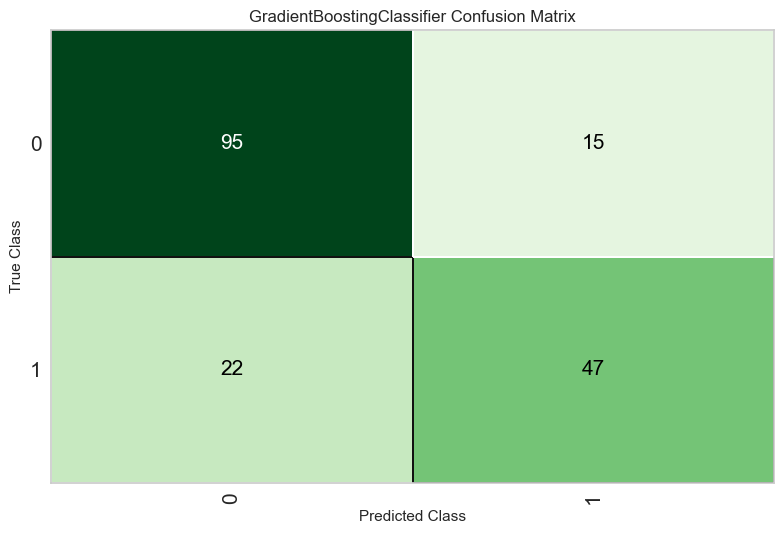

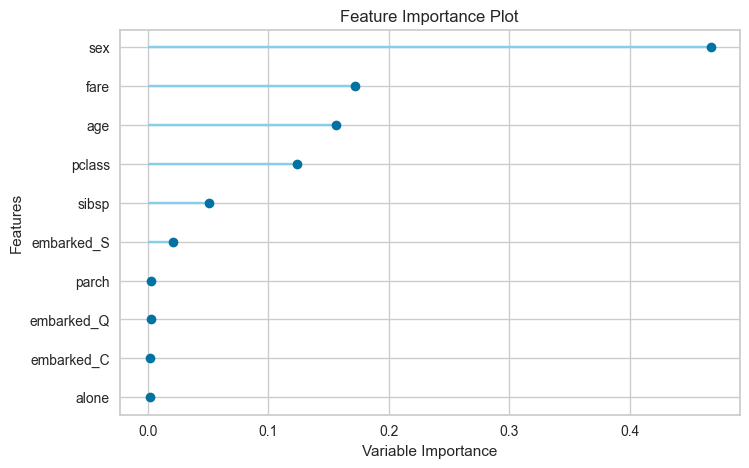

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.7933,0.8530,0.6812,0.7581,0.7176,0.5553,0.5573


--- 정제된 데이터로 모델링 완료 ---


In [1]:
import seaborn as sns
import pandas as pd
from pycaret.classification import *

# 1. 데이터 로드
df = sns.load_dataset('titanic')

# 2. 데이터 정리 (Data Cleaning)
# - alive: 타겟 누수 (survived와 동일)
# - who, adult_male: sex, age와 중복 정보
# - embark_town: embarked와 중복 정보
# - class: pclass와 중복 정보
# - deck: 결측치가 너무 많아(약 77%) 신뢰도가 낮음
drop_cols = ['alive', 'who', 'adult_male', 'embark_town', 'class', 'deck']
df_clean = df.drop(columns=drop_cols)

print("사용할 컬럼 목록:", df_clean.columns.to_list())

# 3. PyCaret 환경 설정 (Setup)
# ignore_features: 위에서 drop하지 않고 setup 함수 내에서 제외할 수도 있지만, 
# 명확성을 위해 미리 전처리한 df_clean을 사용합니다.
s = setup(data = df_clean, 
          target = 'survived', 
          session_id = 123,
          train_size = 0.8,
          preprocess = True) # 결측치 처리 및 인코딩 자동 수행

# 4. 모델 비교 (Compare Models)
# 앙상블 모델들을 포함하여 가장 성능이 좋은 상위 모델을 찾습니다.
best_model = compare_models()

# 5. 모델 분석 및 시각화
# 혼동 행렬 확인
plot_model(best_model, plot = 'confusion_matrix')

# 피처 중요도 (어떤 변수가 생존 예측에 큰 영향을 주었는지 확인)
# 'alive'가 빠졌으므로 이제 sex, fare, age 등이 상위에 나타날 것입니다.
plot_model(best_model, plot = 'feature')

# 6. 최종 예측 및 결과 확인
predictions = predict_model(best_model)
# display(predictions.head())

print("--- 정제된 데이터로 모델링 완료 ---")

In [2]:
# end